# The Fiscal Amplifier: M2-to-Inflation Passthrough Under High Debt

In [ ]:
import datetime

# ===== GLOBAL VARIABLES =====
RELOAD_DATA = False 
TODAY = str(datetime.datetime.now().date())
DEBT_TO_GDP_PERCENTILE = 75
# ============================

### What We Found (Empirical Motivation)
The M2 → CPI passthrough (at 78-week lag) flips from near-zero to 0.80
when debt-to-GDP crosses roughly the 75th percentile of the historical
distribution.

An interaction regression (M2_lag × Debt/GDP → CPI)
yields a coefficient of 0.55 on the interaction term, and adding it
jumps R² from 0.20 to 0.31 (0.77 with energy controls).


Critical caveat we're designing around: the high-debt quartile
is ~75% post-2020. The interaction term dies in a first-differences
specification. So this is better characterized as a structural break
than a smooth moderating effect. The research strategy is therefore
regime-conditional rather than causal.

i.e. expectations are regime-dependent based on this equation:

$$\text{CPI\_YoY} = \beta_0 + \beta_1(\text{M2\_YoY\_Lag78w}) + \beta_2(\text{CPI\_Energy\_YoY}) + \beta_3(\text{Inflation\_Momentum}) + \beta_4(\text{Expect\_Anchor\_Signed}) + \varepsilon$$

#### Get Most Recent Data

In [4]:
# ===== IMPORTS =============
from ResearchFramework.ResearchHandler import ResearchHandler
from ResearchFramework.simulation import *
import ResearchFramework.transforms as tf
from loader import load_fred_master
from macro_scores import score
import pandas as pd
# ============================

# ====== INIT ================
if RELOAD_DATA:
    _ = load_fred_master()
fred = ResearchHandler("data/fred_master.csv", handler=score)
print(f"Today is {TODAY}.")
fred.data = fred.data[fred.data["date"]<=TODAY]
fred.data.tail()
# ============================

Today is 2026-03-27.


,date,Headline_CPI,Core_CPI,PCE_Price_Index,Core_PCE,CPI_Food,CPI_Energy,UMich_Inflation_Expectations,Breakeven_Inflation_5Y,Breakeven_Inflation_10Y,...,Curve_10Y2Y_Lag_52w,Curve_10Y3M_Lag_52w,Breakeven_5Y_Lag_26w,Breakeven_5Y_Lag_52w,Home_Price_YoY_Lag_78w,Credit_Impulse_Lag_13w,Credit_Impulse_Lag_26w,FFR_Chg_52w,FFR_Chg_52w_Lag_52w,Sentiment_Lag_13w
1886,2026-02-27,327.46,333.512,128.969,128.394,346.622,283.223,3.4,2.410,2.266,...,0.234,-1.600000e-02,2.490,2.574,3.544575,1.339104,-6.694157,-0.69,-1.0,51.0
1887,2026-03-06,327.46,333.512,128.969,128.394,346.622,283.223,3.4,2.490,2.306,...,0.282,-9.000000e-02,2.450,2.558,3.911211,0.485018,0.550626,-0.69,-1.0,52.9
1888,2026-03-13,327.46,333.512,128.969,128.394,346.622,283.223,3.4,2.582,2.354,...,0.320,-5.800000e-02,2.416,2.496,3.911211,0.485018,0.550626,-0.69,-1.0,52.9
1889,2026-03-20,327.46,333.512,128.969,128.394,346.622,283.223,3.4,2.620,2.376,...,0.272,-6.600000e-02,2.426,2.492,3.911211,0.485018,0.550626,-0.69,-1.0,52.9
1890,2026-03-27,327.46,333.512,128.969,128.394,346.622,283.223,3.4,2.542,2.324,...,0.362,1.387779e-18,2.420,2.568,3.911211,0.485018,0.550626,-0.69,-1.0,52.9


### Isolate Features

In [5]:
# ===== FEATURE ISOLATION =====
KEEP = [
    "date",
    # ── Primary model (Phase 2b) ──────────────────────
    "CPI_YoY",                          # DV
    "M2_YoY_Lag_78w",                   # IV: M2 passthrough (core)
    "CPI_Energy_YoY",                   # IV: supply shock control
    "Inflation_Momentum",               # IV: 3m vs 12m timing
    "Expect_Anchor_Signed",             # IV: expectations channel
    # ── Regime split ──────────────────────────────────
    "Debt_to_GDP",                       # threshold variable
    # ── Reaction function (Phase 2c) ──────────────────
    "FedFunds_Rate",                     # builds FFR_Change_13w
    "Taylor_Gap",                        # IV
    "Mandate_Tension",                   # IV
    "Policy_Stance_SEP",                 # IV
    # ── Scenario calibration (Phase 4) ────────────────
    "M2_YoY",                            # current M2 for scenario design
    "Core_PCE_YoY",                      # alt DV robustness
    # ── Robustness (Phase 6) ──────────────────────────
    "Unemployment_Rate",                 # borderline control
    "Home_Price_YoY_Lag_78w",            # borderline control (housing)
    "Core_CPI_YoY",                      # alt DV
    # ── Sensitivity / decomposition (Phase 5) ─────────
    "Real_FFR_PCE",                      # real rate context
    "Chicago_Fed_Financial_Conditions",  # FCI contradiction
    "UMich_Inflation_Expectations",      # expectations decomposition
    "Breakeven_Inflation_5Y",            # expectations decomposition
    "Breakeven_Inflation_10Y",           # expectations decomposition
    "JOLTS_UE_Ratio",                    # labor market context
]
fred.data = fred.data[KEEP].reset_index(drop=True)
# =============================
fred.data.tail()

,date,CPI_YoY,M2_YoY_Lag_78w,CPI_Energy_YoY,Inflation_Momentum,Expect_Anchor_Signed,Debt_to_GDP,FedFunds_Rate,Taylor_Gap,Mandate_Tension,...,Core_PCE_YoY,Unemployment_Rate,Home_Price_YoY_Lag_78w,Core_CPI_YoY,Real_FFR_PCE,Chicago_Fed_Financial_Conditions,UMich_Inflation_Expectations,Breakeven_Inflation_5Y,Breakeven_Inflation_10Y,JOLTS_UE_Ratio
1886,2026-02-27,2.434004,2.111067,0.399509,0.293835,0.692000,122.490355,3.64,0.054283,0.238475,...,2.596188,4.4,3.544575,2.472462,1.043812,-0.51740,3.4,2.410,2.266,0.986648
1887,2026-03-06,2.400050,2.510146,1.547833,-1.042336,0.732000,122.490355,3.64,-0.095598,0.198507,...,2.496268,4.4,3.911211,2.401670,1.143732,-0.50300,3.4,2.490,2.306,0.986648
1888,2026-03-13,2.400050,2.510146,1.547833,-1.042336,0.778667,122.490355,3.64,-0.095598,0.198507,...,2.496268,4.4,3.911211,2.401670,1.143732,-0.48796,3.4,2.582,2.354,0.986648
1889,2026-03-20,2.400050,2.510146,1.547833,-1.042336,0.798667,122.490355,3.64,0.004402,0.198507,...,2.496268,4.4,3.911211,2.401670,1.143732,-0.47504,3.4,2.620,2.376,0.986648
1890,2026-03-27,2.400050,2.510146,1.547833,-1.042336,0.755333,122.490355,3.64,0.004402,0.198507,...,2.496268,4.4,3.911211,2.401670,1.143732,-0.47504,3.4,2.542,2.324,0.986648


### Calculate Debt Regimes (High | Low Percentile)

In [11]:
thresh = fred.data["Debt_to_GDP"].quantile(DEBT_TO_GDP_PERCENTILE/100)
print(f"Regime threshold is {DEBT_TO_GDP_PERCENTILE}th percentile of Debt_to_GDP: {thresh:.2f}")
fred.data["Regime"] = fred.data["Debt_to_GDP"].apply(lambda x: "High" if x > thresh else "Low")
high = ResearchHandler(fred.data[fred.data["Regime"]=="High"])
low = ResearchHandler(fred.data[fred.data["Regime"]=="Low"])
print(f"High regime has {len(high.data)} observations, Low regime has {len(low.data)} observations.")

print("Date Range:")
print(f"High regime: {high.data['date'].min().date()} to {high.data['date'].max().date()}")
print(f"Low regime: {low.data['date'].min().date()} to {low.data['date'].max().date()}")

Regime threshold is 75th percentile of Debt_to_GDP: 102.94
High regime has 470 observations, Low regime has 1421 observations.
Date Range:
High regime: 2016-01-01 to 2026-03-27
Low regime: 1990-01-05 to 2019-06-28


### Assign Model Vars

In [ ]:
specs = []
for label, regime in [("Low", low), ("High", high)]:
    
    regime.clear_caches()
    regime.set_dependent("CPI_YoY")
    regime.add_independents("M2_YoY_Lag_78w","CPI_Energy_YoY","Inflation_Momentum","Expect_Anchor_Signed")
    spec = regime.get_spec()
    specs.append(spec)
    print("============================")
    print(f"{label} Regime Model Spec:")
    print(spec)
    print("============================")

Caches cleared
Dependent variable set to: CPI_YoY
Independent variables: ['M2_YoY_Lag_78w', 'CPI_Energy_YoY', 'Inflation_Momentum', 'Expect_Anchor_Signed']
Low Regime Model Spec:
ModelSpec(n=1421, source=full, dependent=CPI_YoY, independents=['M2_YoY_Lag_78w', 'CPI_Energy_YoY', 'Inflation_Momentum', 'Expect_Anchor_Signed'], controls=[])
Caches cleared
Dependent variable set to: CPI_YoY
Independent variables: ['M2_YoY_Lag_78w', 'CPI_Energy_YoY', 'Inflation_Momentum', 'Expect_Anchor_Signed']
High Regime Model Spec:
ModelSpec(n=470, source=full, dependent=CPI_YoY, independents=['M2_YoY_Lag_78w', 'CPI_Energy_YoY', 'Inflation_Momentum', 'Expect_Anchor_Signed'], controls=[])


In [21]:
results = {}
for label, spec in [("Low", specs[0]), ("High", specs[1])]:
    X = sm.add_constant(spec.X)
    y = spec.y
    
    # Drop rows with NaN in X or y
    mask = X.notna().all(axis=1) & y.notna()
    X_clean = X[mask]
    y_clean = y[mask]
    
    model = sm.OLS(y_clean, X_clean).fit(cov_type="HAC", cov_kwds={"maxlags": 26})
    results[label] = model
    print(f"\n{'='*60}")
    print(f"{label} Debt Regime (n={len(y_clean)})")
    print(f"{'='*60}")
    print(model.summary())


Low Debt Regime (n=1291)
                            OLS Regression Results                            
Dep. Variable:                CPI_YoY   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     146.6
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          2.44e-103
Time:                        18:37:03   Log-Likelihood:                -597.56
No. Observations:                1291   AIC:                             1205.
Df Residuals:                    1286   BIC:                             1231.
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const 

---

# Regime-Conditional Inflation Model — Statistical Breakdown

## Specification

$$\text{CPI\_YoY} = \beta_0 + \beta_1(\text{M2\_YoY\_Lag78w}) + \beta_2(\text{CPI\_Energy\_YoY}) + \beta_3(\text{Inflation\_Momentum}) + \beta_4(\text{Expect\_Anchor\_Signed}) + \varepsilon$$

Estimated separately under two debt regimes split at the 75th percentile of Debt/GDP (~103%).
Standard errors are Newey-West (HAC) with 26-lag bandwidth to correct for severe autocorrelation in weekly level data.

---

## Coefficient Comparison

| Variable | Low Debt (β) | Low (SE) | Low (p) | High Debt (β) | High (SE) | High (p) |
|---|--:|--:|--:|--:|--:|--:|
| **Intercept** | 2.444 | 0.171 | <0.001 | 1.441 | 0.234 | <0.001 |
| **M2_YoY_Lag_78w** | **-0.125** | 0.017 | <0.001 | **+0.119** | 0.025 | <0.001 |
| **CPI_Energy_YoY** | 0.083 | 0.005 | <0.001 | 0.050 | 0.013 | <0.001 |
| **Inflation_Momentum** | -0.166 | 0.084 | 0.048 | -0.207 | 0.104 | 0.047 |
| **Expect_Anchor_Signed** | 0.412 | 0.158 | 0.009 | **1.511** | 0.251 | <0.001 |

| Fit Statistic | Low Debt | High Debt |
|---|--:|--:|
| n | 1,291 | 470 |
| R² | 0.885 | 0.907 |
| Adj. R² | 0.884 | 0.906 |
| Residual Std. | ~0.39 | ~0.65 |
| Durbin-Watson | 0.081 | 0.092 |
| F-statistic | 146.6 | 213.2 |

---

## Interpretation by Variable

### M2_YoY_Lag_78w — The Core Finding

This is the fiscal amplifier result. The coefficient flips sign across regimes and is highly significant in both (p < 0.001).

**Low debt: β = -0.125.** A 1 percentage point increase in M2 growth (18 months ago) is associated with 0.125pp *lower* CPI today. This is counterintuitive at first, but it's consistent with the pre-2020 monetary environment where M2 expansion was primarily QE — reserves sitting in the banking system, never reaching the real economy. Faster M2 growth during that era coincided with recessions and disinflation (the Fed was expanding M2 *because* inflation was low), so the negative sign captures reverse causality in the low-debt regime.

**High debt: β = +0.119.** The same 1pp increase in lagged M2 growth is associated with 0.119pp *higher* CPI. The passthrough has activated. In the post-2016 high-debt environment — and especially post-2020 — M2 expansion reached households directly through fiscal transfers (stimulus checks, expanded UI, PPP). Money supply growth actually translated into spending and prices.

**The swing: 0.244pp per 1pp of M2 growth.** From -0.125 to +0.119, the total regime-dependent difference is ~0.24pp of CPI per percentage point of M2 growth. For the COVID-era M2 surge (~25% YoY growth versus a ~5% baseline), the model implies the high-debt regime amplified inflation by roughly 25 × 0.24 ≈ 6pp relative to what the low-debt regime coefficients would have predicted. That's the fiscal amplifier.

### CPI_Energy_YoY — Supply Shock Control

Positive and significant in both regimes, as expected. Energy passes through to headline CPI mechanically (energy is ~7% of the CPI basket).

**Low debt: β = 0.083. High debt: β = 0.050.** The smaller coefficient in the high-debt regime is notable — it suggests that during the post-2016 period, energy shocks explain less of CPI variation because demand-side forces (M2, expectations) dominate. Energy is still significant but its relative importance has diminished.

### Inflation_Momentum — Timing Adjustment

Negative in both regimes, marginally significant (p ≈ 0.048 in both). When the 3-month annualized Core PCE rate is running above the 12-month rate (positive momentum = reacceleration), the model predicts slightly lower CPI_YoY.

This is a mechanical timing artifact: momentum captures acceleration that hasn't yet fully propagated into the 12-month headline number. The coefficient is essentially a correction for the lag between high-frequency price moves and the YoY rate. It's the weakest regressor in both models and could arguably be dropped — the R² cost is minimal (ΔR² ≈ 0.005 when removed from the high-debt model).

### Expect_Anchor_Signed — The Secondary Finding

**Low debt: β = 0.412. High debt: β = 1.511.** This is nearly a 4× amplification.

In the low-debt regime, a 1pp upward drift in average inflation expectations above the 2% target is associated with 0.41pp higher CPI. Expectations matter, but the pass-through is partial — the Fed's credibility anchor holds.

In the high-debt regime, the same 1pp expectations drift maps to 1.51pp higher CPI. Expectations are passing through more than one-for-one into realized inflation. This is consistent with a loss of anchoring — when agents doubt the Fed's ability or willingness to control inflation (potentially because they see the fiscal trajectory as constraining monetary policy), their expectations become self-fulfilling.

This is arguably as important a finding as the M2 result. It suggests that the fiscal environment doesn't just amplify the M2 channel — it also amplifies the expectations channel. Both mechanisms by which inflation propagates become more potent under high debt.

---

## Diagnostic Concerns

### Durbin-Watson: 0.081 (Low), 0.092 (High)

These are extremely low. A DW statistic near 0 indicates severe positive autocorrelation in the residuals. For reference, a DW of 2.0 indicates no autocorrelation. Values below 0.5 are considered highly problematic for standard inference.

**Why this is happening:** CPI_YoY is a 12-month rolling measure computed from weekly data. Adjacent weeks share 51 of 52 data points — the residuals are mechanically correlated. The underlying price level is also highly persistent (AR(1) > 0.99).

**Why it's partially addressed:** The Newey-West HAC standard errors with 26-lag bandwidth correct for this when computing confidence intervals and p-values. The coefficient estimates themselves are still unbiased and consistent under OLS — autocorrelation doesn't bias β, it biases standard errors, and HAC fixes that.

**What it doesn't fix:** The DW statistic suggests the residuals follow something close to a unit root process. This means the R² values (0.885 and 0.907) are likely inflated by the shared persistence between the dependent and independent variables — persistent series tend to co-move, producing high R² even without a genuine economic relationship. This is the classic spurious regression concern with I(1) or near-I(1) level variables.

**Mitigation options (for robustness section):**
1. Re-estimate in first differences (13-week changes). We already know the interaction dies in differences, but checking whether the individual regime coefficients hold is valuable.
2. Re-estimate at quarterly frequency (every 13th observation) to reduce the overlapping-window mechanical autocorrelation.
3. Report both the levels and differences specifications side by side and let the reader assess.

### Jarque-Bera: Significant in Both Regimes

The residuals are not normally distributed (p < 0.001 in both). The low-debt model has excess kurtosis (4.69 vs. normal of 3.0), meaning fat tails — there are more extreme residual observations than a Gaussian would predict. This doesn't bias OLS estimates but means confidence intervals based on normality assumptions are approximate. With n > 400 in both regimes, the CLT provides reasonable coverage regardless.

### Condition Number: 53 (Low), 40 (High)

These are clean — condition numbers below 100 indicate no serious multicollinearity. Consistent with the VIF checks we ran earlier (all below 4.3).

---

## What This Means for the Simulation

The two estimated models give us the parameters to plug into regime-conditional Monte Carlo simulation:

**High-debt model function:**
$$\hat{Y} = 1.441 + 0.119 \cdot M2 + 0.050 \cdot Energy + (-0.207) \cdot Momentum + 1.511 \cdot Expectations$$

**Low-debt model function:**
$$\hat{Y} = 2.444 + (-0.125) \cdot M2 + 0.083 \cdot Energy + (-0.166) \cdot Momentum + 0.412 \cdot Expectations$$

The residual standard deviations (~0.39 in low debt, ~0.65 in high debt) become the noise term in the simulation — draw from N(0, σ_resid) and add to the predicted value for each iteration. The larger residual variance in the high-debt regime is itself meaningful: inflation outcomes are inherently less predictable under fiscal stress.

For `Simulation.from_spec()`, use the high-debt spec to fit input distributions for the scenario analysis, since we're interested in forward-looking questions about the current (high-debt) environment.

---

# Simulation under different Regimes

In [23]:
betas = {}
for label, model in results.items():
    betas[label] = {
        "const":               model.params["const"],
        "M2_YoY_Lag_78w":      model.params["M2_YoY_Lag_78w"],
        "CPI_Energy_YoY":      model.params["CPI_Energy_YoY"],
        "Inflation_Momentum":  model.params["Inflation_Momentum"],
        "Expect_Anchor_Signed":model.params["Expect_Anchor_Signed"],
        "resid_std":           model.resid.std(),
    }
    print(f"\n{label} regime:")
    for k, v in betas[label].items():
        print(f"  {k:<25s}: {v:+.6f}")


Low regime:
  const                    : +2.444051
  M2_YoY_Lag_78w           : -0.124547
  CPI_Energy_YoY           : +0.082660
  Inflation_Momentum       : -0.165498
  Expect_Anchor_Signed     : +0.412282
  resid_std                : +0.384550

High regime:
  const                    : +1.441235
  M2_YoY_Lag_78w           : +0.119318
  CPI_Energy_YoY           : +0.049706
  Inflation_Momentum       : -0.206651
  Expect_Anchor_Signed     : +1.510847
  resid_std                : +0.658022


---

# Feed Betas to Monte Carlo Model

In [24]:
# ===== MONTE CARLO SIMULATION =====

# Model functions using estimated coefficients
def make_model(b):
    """Build a row-wise model function from a coefficient dict."""
    def model(row):
        return (
            b["const"]
            + b["M2_YoY_Lag_78w"]       * row["M2_YoY_Lag_78w"]
            + b["CPI_Energy_YoY"]       * row["CPI_Energy_YoY"]
            + b["Inflation_Momentum"]   * row["Inflation_Momentum"]
            + b["Expect_Anchor_Signed"] * row["Expect_Anchor_Signed"]
            + np.random.normal(0, b["resid_std"])
        )
    return model

sims = {}
for label, spec, beta in [("Low", specs[0], betas["Low"]),
                           ("High", specs[1], betas["High"])]:
    sim = Simulation.from_spec(
        spec,
        model=make_model(beta),
        dist_type="normal",
        overrides={
            "CPI_Energy_YoY": {"dist_type": "normal"},      # wide variance is real
            "Inflation_Momentum": {"dist_type": "normal"},
        },
        n_iterations=10_000,
        seed=42,
    )
    sims[label] = sim
    print(f"\n{label} regime simulation ready:")
    print(f"  Variables: {sim.input_manager.variable_names}")
    print(f"  Iterations: {sim.n_iterations}")


# Run both and summarize
for label, sim in sims.items():
    result = sim.run()
    print(f"\n{label} Debt Regime — CPI_YoY distribution:")
    print(f"  Mean:   {result.mean:.2f}%")
    print(f"  Median: {result.median:.2f}%")
    print(f"  Std:    {result.std:.2f}")
    print(f"  95% CI: [{result.ci_lower:.2f}%, {result.ci_upper:.2f}%]")


Low regime simulation ready:
  Variables: ['M2_YoY_Lag_78w', 'CPI_Energy_YoY', 'Inflation_Momentum', 'Expect_Anchor_Signed']
  Iterations: 10000

High regime simulation ready:
  Variables: ['M2_YoY_Lag_78w', 'CPI_Energy_YoY', 'Inflation_Momentum', 'Expect_Anchor_Signed']
  Iterations: 10000

Low Debt Regime — CPI_YoY distribution:
  Mean:   2.35%
  Median: 2.34%
  Std:    1.14
  95% CI: [0.14%, 4.56%]

High Debt Regime — CPI_YoY distribution:
  Mean:   3.28%
  Median: 3.26%
  Std:    2.14
  95% CI: [-0.95%, 7.47%]


# Scenarios:

In [25]:
# ===== SCENARIO COMPARISON =====

scenarios = [
    Scenario("M2_at_4pct", overrides={
        "M2_YoY_Lag_78w": {"mean": 4.0, "std": 1.5},
    }),
    Scenario("M2_at_8pct", overrides={
        "M2_YoY_Lag_78w": {"mean": 8.0, "std": 2.0},
    }),
    Scenario("M2_at_12pct", overrides={
        "M2_YoY_Lag_78w": {"mean": 12.0, "std": 3.0},
    }),
    Scenario("M2_surge_20pct", overrides={
        "M2_YoY_Lag_78w": {"mean": 20.0, "std": 4.0},
    }),
]

for label, sim in sims.items():
    print(f"\n{'='*60}")
    print(f"{label} Debt Regime — Scenario Comparison")
    print(f"{'='*60}")
    summary = sim.compare_scenarios_summary(scenarios)
    print(summary.to_string(index=False, float_format="%.2f"))


Low Debt Regime — Scenario Comparison
      scenario  mean  median  std  ci_lower  ci_upper   min  max
      baseline  2.35    2.35 1.13      0.10      4.57 -1.87 6.32
    M2_at_4pct  2.53    2.53 1.11      0.34      4.70 -1.39 6.43
    M2_at_8pct  2.03    2.03 1.12     -0.15      4.25 -2.03 6.41
   M2_at_12pct  1.53    1.54 1.16     -0.76      3.84 -2.87 5.81
M2_surge_20pct  0.54    0.54 1.21     -1.88      2.94 -4.04 5.49

High Debt Regime — Scenario Comparison
      scenario  mean  median  std  ci_lower  ci_upper   min   max
      baseline  3.27    3.25 2.15     -0.88      7.50 -4.43 11.06
    M2_at_4pct  2.95    2.95 1.68     -0.30      6.30 -3.59  9.05
    M2_at_8pct  3.43    3.42 1.70      0.13      6.79 -3.48  9.83
   M2_at_12pct  3.91    3.91 1.78      0.38      7.40 -2.89 10.30
M2_surge_20pct  4.87    4.85 1.86      1.26      8.55 -2.93 11.70


In [26]:
# ===== SENSITIVITY ANALYSIS =====

print("High Debt Regime — Tornado Sensitivity")
print("="*60)
tornado_high = sims["High"].sensitivity.tornado()
print(tornado_high.to_string(index=False, float_format="%.3f"))

print(f"\nLow Debt Regime — Tornado Sensitivity")
print("="*60)
tornado_low = sims["Low"].sensitivity.tornado()
print(tornado_low.to_string(index=False, float_format="%.3f"))

High Debt Regime — Tornado Sensitivity
            variable  low_value  high_value  low_outcome  high_outcome  swing
Expect_Anchor_Signed     -0.218       1.329        1.951         4.633  2.682
      CPI_Energy_YoY    -13.181      20.271        2.290         3.910  1.620
      M2_YoY_Lag_78w     -2.638      16.071        2.467         3.903  1.436
  Inflation_Momentum     -1.083       1.140        4.455         3.456  0.999

Low Debt Regime — Tornado Sensitivity
            variable  low_value  high_value  low_outcome  high_outcome  swing
      CPI_Energy_YoY    -10.422      17.489        0.939         3.788  2.849
      M2_YoY_Lag_78w      2.335       8.520        2.656         1.595  1.061
  Inflation_Momentum     -0.721       0.620        2.542         1.629  0.912
Expect_Anchor_Signed     -0.093       1.354        2.153         2.678  0.526


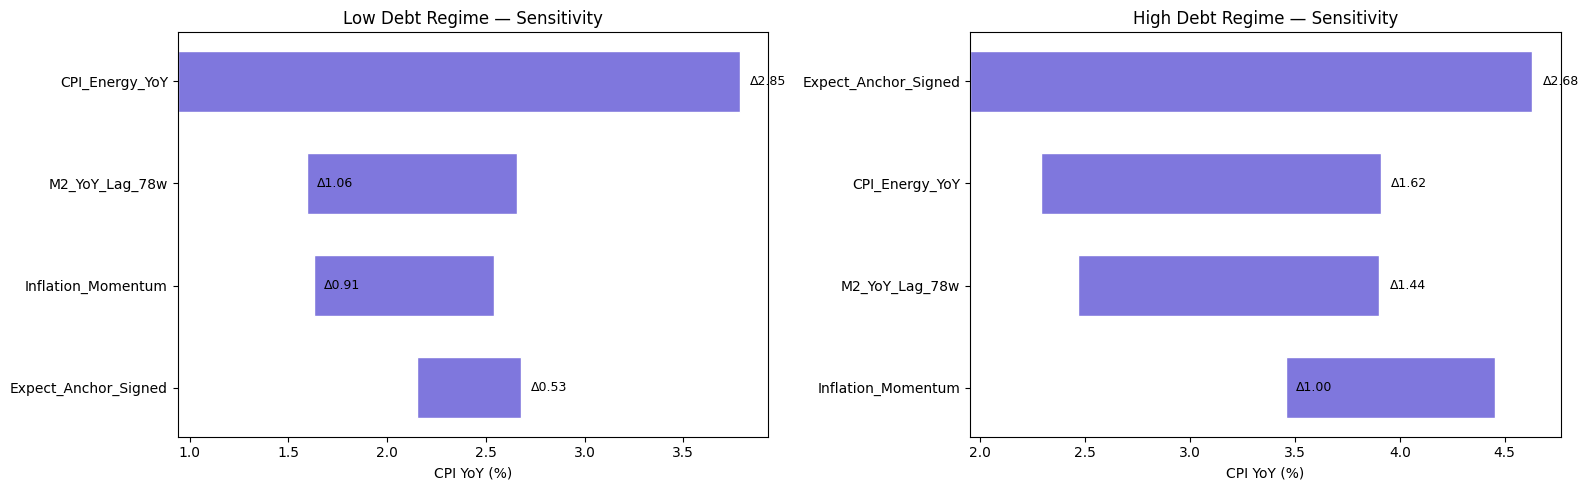

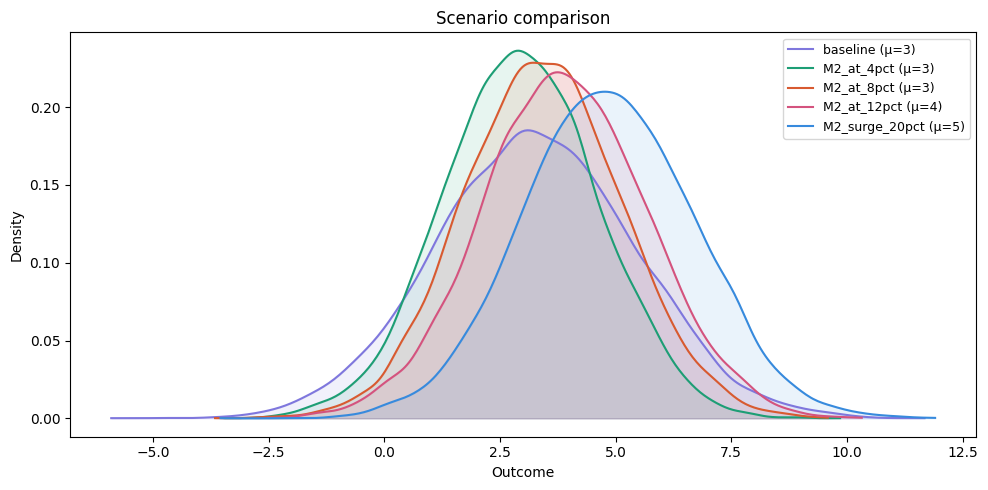

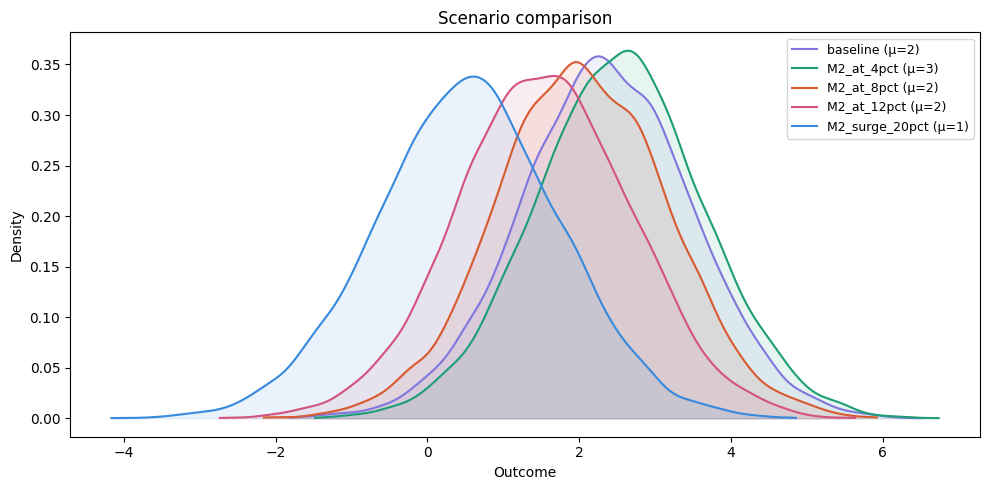

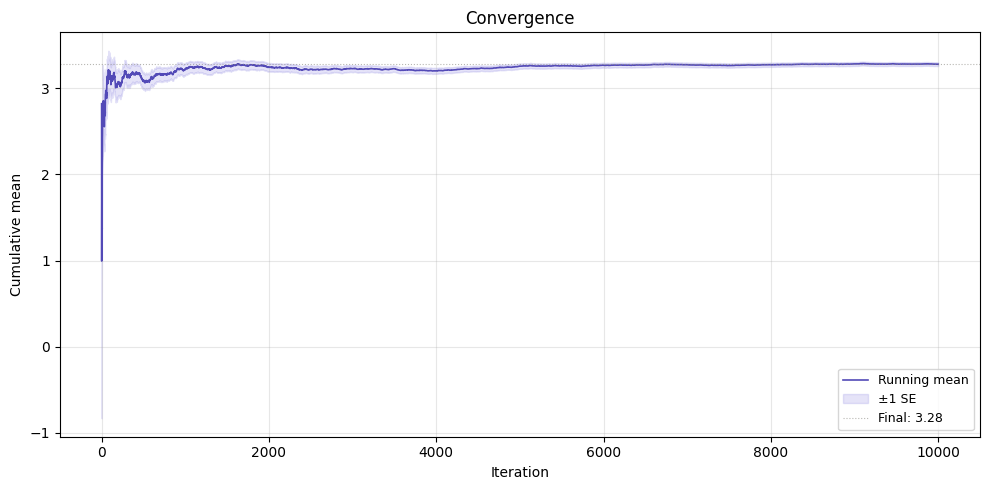


Low regime convergence:
  is_converged: False
  suggested_n: 36368
  current_n: 10000
  relative_se: 0.0048649844537479925

High regime convergence:
  is_converged: True
  suggested_n: 66611
  current_n: 10000
  relative_se: 0.006584065692413432


In [28]:
# ===== VISUALIZATION =====

# 1. Scenario comparison — overlaid KDEs for both regimes
high_scenario_results = sims["High"].compare_scenarios(scenarios)
low_scenario_results = sims["Low"].compare_scenarios(scenarios)

# 2. Side-by-side tornado charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tornado, label in [(axes[0], tornado_low, "Low Debt"),
                            (axes[1], tornado_high, "High Debt")]:
    df_t = tornado.sort_values("swing", ascending=True)
    y_pos = np.arange(len(df_t))
    lefts = df_t["low_outcome"].values
    widths = df_t["high_outcome"].values - df_t["low_outcome"].values
    ax.barh(y_pos, widths, left=lefts, height=0.6, color="#7F77DD", edgecolor="white")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_t["variable"].values)
    ax.set_xlabel("CPI YoY (%)")
    ax.set_title(f"{label} Regime — Sensitivity")
    for i, (_, row) in enumerate(df_t.iterrows()):
        ax.text(row["high_outcome"] + 0.05, i, f"Δ{row['swing']:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("charts/tornado_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Scenario KDE comparison — High debt regime
fig = sims["High"].plot.scenario_comparison(high_scenario_results)
fig.savefig("charts/high_debt_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Scenario KDE comparison — Low debt regime
fig = sims["Low"].plot.scenario_comparison(low_scenario_results)
fig.savefig("charts/low_debt_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. Convergence check
high_baseline = high_scenario_results["baseline"]
fig = sims["High"].plot.convergence_plot(high_baseline.outcomes)
fig.savefig("charts/convergence_high.png", dpi=150, bbox_inches="tight")
plt.show()

# 6. Convergence diagnostics
for label, sim in sims.items():
    result = sim.run()
    conv = sim.check_convergence(result)
    print(f"\n{label} regime convergence:")
    for k, v in conv.items():
        print(f"  {k}: {v}")